[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/parallelization.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239934-lesson-1-parallelization)

# Parallel node execution

## 回顧

在 module 3，我們深入探討了 `human-in-the-loop`，並展示了 3 種常見的使用情境：

(1) `Approval`（核可）- 我們可以中斷 agent，把 state 呈現給使用者，並讓使用者接受某個動作

(2) `Debugging`（除錯）- 我們可以倒帶 graph 以重現或避免問題

(3) `Editing`（編輯）- 你可以修改 state

## 目標

本 module 會建立在 `human-in-the-loop`，以及 module 2 討論過的 `memory` 概念之上。

我們會深入探討 `multi-agent` 工作流程，並一步步建立一個 multi-agent research assistant，把本課程所有 module 串接起來。

為了打造這個 multi-agent research assistant，我們會先討論幾個 LangGraph 可控性（controllability）的主題。

我們先從 [parallelization](https://docs.langchain.com/oss/python/langgraph/how-tos/graph-api#create-branches) 開始。

## Fan out 與 fan in

讓我們建立一個簡單的線性 graph，它會在每一步覆寫（over-write）state。

In [ ]:
%%capture --no-stderr
%pip install -U  langgraph langchain-tavily wikipedia langchain_openai langchain_community langgraph_sdk

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

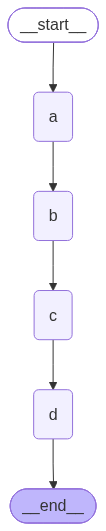

In [1]:
from IPython.display import Image, display

from typing import Any, List
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    # ⚠️ 這行是本章的伏筆：state 沒有掛 reducer。
    # 沒 reducer = 後寫的人直接蓋掉前面的值（就是普通 dict 賦值的行為）。
    # 現在是 a→b→c→d 一條直線，同一時間只有一個 node 在寫，
    # 蓋來蓋去也不會出事，所以沒 reducer 也活得下去。
    # 下一段把 b 和 c 改成平行，這行就會當場拋錯給你看。
    state: List[str]

class ReturnNodeValue:
    # 為什麼 node 用 class 而不是函式？這是 Python 技巧，跟 LangGraph 無關：
    # __init__ 讓每個實例記住自己那份 node_secret，__call__ 讓實例可以像函式一樣被呼叫。
    # 所以一個 class 就能生出 a/b/c/d 四個「行為一模一樣、只有值不同」的 node。
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state['state']}")
        return {"state": [self._value]}

# 加入 node
builder = StateGraph(State)

# 以 node_secret 初始化每個 node
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 流程
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

如預期一般，我們覆寫了 state。

In [3]:
# 輸出只剩 {'state': ["I'm D"]}——A、B、C 全被蓋掉了，這就是「沒有 reducer」的樣子。
# 每個 node 都回傳 {"state": [...]}，沒 reducer 就是「整個 key 換成新值」。
# 先記住這個「覆寫」的畫面，等一下修好之後拿來對照。
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm B"]
Adding I'm D to ["I'm C"]


{'state': ["I'm D"]}

現在，讓我們把 `b` 和 `c` 平行執行。

然後再執行 `d`。

我們可以很輕鬆地做到：從 `a` fan-out 到 `b` 和 `c`，然後再 fan-in 到 `d`。

state 的更新會在每一步結束時套用。

讓我們執行看看。

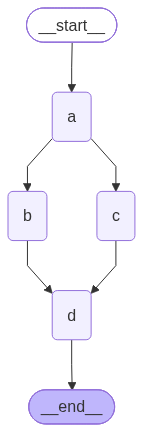

In [4]:
# 這次只改了 edge：原本 a→b→c→d 一直線，現在變成 a 之後同時分岔到 b 和 c
# （fan-out），再收斂回 d（fan-in）。State 完全沒動，還是上面那個沒有 reducer 的版本。
# 這個 cell 只是 compile + 畫圖，還不會爆——真正的爆炸在下一個 cell。
builder = StateGraph(State)

# 以 node_secret 初始化每個 node
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 流程
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")   # ← 改這裡：a 同時往 b 和 c 送，b 和 c 會落在同一步裡
builder.add_edge("b", "d")
builder.add_edge("c", "d")   # ← 兩條分支再收斂回 d
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

**我們看到一個錯誤**！

這是因為 `b` 和 `c` 在同一步（step）中寫入了同一個 state key／channel。

In [5]:
# ⚠️ 踩雷：整章最重要的一格。這裡會拋 InvalidUpdateError，而且是故意讓它拋的。
#
# 缺的前提是 super-step：LangGraph 不是一個 node 一個 node 慢慢跑，
# 而是一步一步（super-step）往前推——同一步裡「所有準備好的 node」一起跑。
# a 跑完是第一步；接著 b 和 c 同時準備好，所以它們在「同一步」裡一起跑。
# 不是 b 先 c 後，是真的同時。
#
# 於是這一步結束時，LangGraph 手上有兩份對同一個 key 的更新：
#   b 說 state = ["I'm B"]，c 說 state = ["I'm C"]
# 沒有 reducer，它不知道該聽誰的，也不會自己猜 → 直接拋錯。
#
# 錯誤訊息 "Can receive only one value per step. Use an Annotated key" 翻成人話：
#   「同一步裡有兩個 node 想寫同一個 key，你沒告訴我怎麼合併，我不猜。」
#
# 看 print 的輸出：B 和 C 都印 "Adding ... to ["I'm A"]"，兩個看到的都只有 A。
# 誰都沒看到對方——這就是它們同步開跑的鐵證。
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"state": []})
except InvalidUpdateError as e:
    print(f"An error occurred: {e}")

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
An error occurred: At key 'state': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


在使用 fan out 時，如果多個步驟要寫入同一個 channel／key，我們必須確保有使用 reducer。

如同我們在 Module 2 提到的，`operator.add` 是 Python 內建 operator 模組中的一個函式。

當 `operator.add` 套用在 list 上時，它會執行 list 串接（concatenation）。

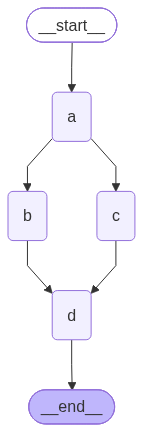

In [6]:
import operator
from typing import Annotated

class State(TypedDict):
    # 這就是解法，而且是唯一的改動——graph 結構跟上面爆炸那版一模一樣。
    #
    # Annotated[型別, reducer] 讀作：
    #   「這個欄位會被多個 node 同時寫；衝突的時候，用後面這個函式把它們合併。」
    # 前面的 list 是給人和型別檢查器看的，後面的 operator.add 才是給 LangGraph 看的。
    #
    # operator.add 套在兩個 list 上就是相接：["I'm B"] + ["I'm C"] → ["I'm B", "I'm C"]。
    # 所以 b 和 c 的更新不再互相覆蓋，而是各自 append 上去。
    #
    # ⚠️ 前提揭露：reducer 不是效能優化，也不是「順手加的好習慣」。
    #    它是平行寫入的必要條件——只要想 fan-out 寫同一個 key，就一定得有它。
    state: Annotated[list, operator.add]

# 加入 node
builder = StateGraph(State)

# 以 node_secret 初始化每個 node
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 流程
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# 不爆了，輸出 ["I'm A", "I'm B", "I'm C", "I'm D"]。
#
# ⚠️ 踩雷：不要把「B 排在 C 前面」當成保證。
#    比對一下 print 的順序——實際上是 C 先跑、B 後跑，合併出來的結果卻是 B 在前面。
#    誰先執行、誰的更新先被合併，是 LangGraph 依 graph 拓樸決定的，
#    跟你 add_edge 的順序有關但不等於它，更不該拿來當依賴。
#    今天看起來穩定，只是這張圖剛好長這樣。
#    真的需要可重現的順序 → 就是下面 sorting_reducer 那段要解的問題。
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm D"]}

現在我們看到，對於 `b` 和 `c` 平行做出的更新，我們是用附加（append）的方式寫入 state。

## 等待 node 完成

現在，讓我們考慮一種情況：其中一條平行路徑的步驟數比另一條多。

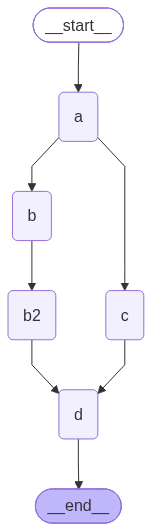

In [8]:
# 這次改的是分支長度：b 後面多接一站 b2，c 那條還是只有一站。
# 重點全在最後那條 fan-in edge 的寫法。
builder = StateGraph(State)

# 以 node_secret 初始化每個 node
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 流程
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")   # ← 這次新增：b 這條分支變兩站，c 那條仍是一站

# 第一個參數是 list：「等 b2 和 c 兩個都跑完，才准跑 d」——這是一個 join（匯流點）。
# d 會等最長的那條分支，所以 c 早就跑完也得空等 b2。
#
# ⚠️ 踩雷：這裡不能拆成 add_edge("b2","d") + add_edge("c","d") 兩行。
#    分支長度一樣時（上面 b/c 那版）兩種寫法結果相同，很容易以為可以互換；
#    但這裡長度不同，拆成兩行會讓 d 跑「兩次」——c 跑完先觸發一次 d，
#    b2 跑完再觸發一次 d，最後 state 裡會出現兩個 "I'm D"。
#    list 寫法才是真正的「等全部到齊，只跑一次」。
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

在這個案例中，`b`、`b2` 和 `c` 都屬於同一步（step）。

graph 會等待這些全部完成後，才繼續進入步驟 `d`。

In [10]:
# 看 print：b2 是在 b 和 c 都跑完之後才跑的（它看到的 state 已經有 B 和 C 了）。
#
# ⚠️ 上面 markdown 說「b、b2 和 c 都屬於同一步（step）」——這句跟這裡的輸出對不上，
#    原始教材寫得不精確，照著念會把 super-step 教錯。實際的 super-step 是：
#      第 1 步 a ／ 第 2 步 b、c（同時）／ 第 3 步 b2 ／ 第 4 步 d
#    b2 要吃 b 的結果，不可能跟 b 同一步。
#    要講的話應該說「b、b2、c 都屬於同一段平行區段，d 等整段跑完」。
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

## 設定 state 更新的順序

然而，在每一步之內，我們無法明確控制 state 更新的順序！

簡單來說，這是一個由 LangGraph 根據 graph 拓樸（topology）決定的確定性順序，是**我們無法控制的**。

在上面的例子中，我們看到 `c` 在 `b2` 之前被加入。

不過，我們可以使用自訂的 reducer 來客製化這個行為，例如：對 state 更新排序。

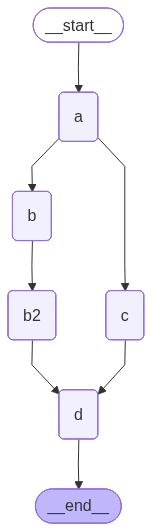

In [11]:
def sorting_reducer(left, right):
    """ 合併並排序 list 中的值 """
    # reducer 的簽名固定就是這兩個參數，意思是：
    #   left  = 已經累積在 state 裡的舊值
    #   right = 這次 node 新回傳的值
    #   回傳值 = 合併後的新 state（LangGraph 拿它整個換掉這個 key）
    # operator.add 能當 reducer，就是因為它剛好符合這個「(舊, 新) → 新」的形狀。
    #
    # 這兩個 isinstance 是防呆：第一次合併時 left 可能是單一值而不是 list，
    # 直接 left + right 會炸。先都包成 list 再合併。
    if not isinstance(left, list):
        left = [left]

    if not isinstance(right, list):
        right = [right]
    
    return sorted(left + right, reverse=False)

class State(TypedDict):
    # 它存在的理由：既然平行分支的完成順序不保證（就是上面 B/C 那個坑），
    # 那就別跟它硬拚——在 reducer 裡直接排序，讓輸出變成可重現（deterministic）。
    # 換句話說：放棄「執行順序」這個標準，改用「值本身的順序」。
    #
    # ⚠️ 踩雷：它排的是「值」，不是「執行順序」，而且每次合併都全域重排一次。
    #    這裡輸出剛好是 A→B→B2→C→D、看起來像執行順序，純粹是 node 的值取得剛好；
    #    如果 a 那個 node 的值改叫 "I'm Z"，它會被排到最後面，即使它第一個跑。
    state: Annotated[list, sorting_reducer]

# 加入 node
builder = StateGraph(State)

# 以 node_secret 初始化每個 node
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# 流程
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2", "c"], "d")
builder.add_edge("d", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"state": []})

Adding I'm A to []
Adding I'm C to ["I'm A"]
Adding I'm B to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm B2", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm B2", "I'm C", "I'm D"]}

現在，reducer 會把更新後的 state 值排序！

`sorting_reducer` 這個例子會把所有值做全域排序。我們也可以：

1. 在平行步驟中，把輸出寫到 state 中一個獨立的欄位
2. 在平行步驟之後，使用一個「sink」node 來合併並排序這些輸出
3. 合併完成後，清除那個暫時的欄位

<!-- See the [~docs~](https://langchain-ai.github.io/langgraph/how-tos/branching/#stable-sorting) [docs](https://docs.langchain.com/oss/python/langgraph/how-tos/graph-api#create-branches) for more details.-->


## 與 LLM 一起運作

現在，讓我們加入一個更貼近實務的例子！

我們想從兩個外部來源（Wikipedia 與 Web-Search）蒐集 context，並讓 LLM 回答一個問題。

In [13]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o", temperature=0) 

In [14]:
class State(TypedDict):
    # 這個對比是整章的收斂點，值得停下來問學員：為什麼只有 context 有 reducer？
    #
    # question：使用者一開始傳進來，沒有 node 會改它  → 沒人搶著寫 → 不用 reducer
    # answer  ：只有 generate_answer 一個 node 會寫    → 沒人搶著寫 → 不用 reducer
    # context ：search_web 和 search_wikipedia 會「同時」往它寫 → 一定要 reducer
    #
    # 判準就一句話：這個 key 會不會在同一個 super-step 裡被多個 node 寫？
    # 會 → 用 Annotated 掛 reducer；不會 → 普通型別就好。
    question: str
    answer: str
    context: Annotated[list, operator.add]

你可以嘗試不同的 web search 工具。[Tavily](https://tavily.com/) 是一個值得考慮的好選擇，但請確保你已設定 `TAVILY_API_KEY`。

In [15]:
import os, getpass
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
_set_env("TAVILY_API_KEY")

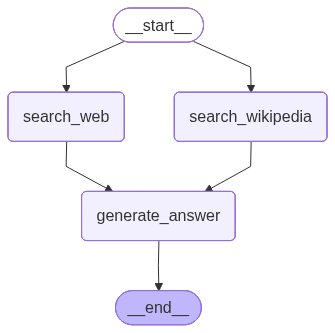

In [16]:
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.document_loaders import WikipediaLoader
from langchain_tavily import TavilySearch  # 影片拍攝後 Tavily 已改套件，這是新版的 import

def search_web(state):
    
    """ 從 web search 取得文件 """
    # fan-out 的其中一隻手。它跟 search_wikipedia 之間沒有任何先後關係，兩個同時開跑。

    # 搜尋
    tavily_search = TavilySearch(max_results=3)
    data = tavily_search.invoke({"query": state['question']})
    # 新版 TavilySearch 回傳 {"results": [...]} 這種 dict，舊版直接回傳 list。
    # 這行只是為了兩種都吃得下，不是什麼特別的邏輯。
    search_docs = data.get("results", data)

     # 格式化
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}">\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    # 這裡寫的 context，跟 search_wikipedia 寫的是「同一個 key、同一個 super-step」。
    # 前面那個 InvalidUpdateError 就是在這種情況下炸的——
    # 所以上面的 State 才非得把 context 宣告成 Annotated[list, operator.add] 不可。
    return {"context": [formatted_search_docs]} 

def search_wikipedia(state):
    
    """ 從 wikipedia 取得文件 """
    # fan-out 的另一隻手。兩邊都是網路 I/O：序列跑是 1+1，平行跑約等於比較慢的那一個。
    # 這就是這一整章拿 reducer 換來的東西——時間。

    # 搜尋
    search_docs = WikipediaLoader(query=state['question'], 
                                  load_max_docs=2).load()

     # 格式化
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}">\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 

def generate_answer(state):
    
    """ 回答問題的 node """
    # 這是 fan-in 點：跑到這裡時，LangGraph 保證兩個 search 都已經回來了。
    # 所以 state["context"] 裡是被 operator.add 接好的兩份資料（wikipedia + web）。
    # 你不必自己寫任何等待或合併的程式碼——fan-in edge 和 reducer 已經替你做完了。

    # 取得 state
    context = state["context"]
    question = state["question"]

    # 模板
    answer_template = """Answer the question {question} using this context: {context}"""
    answer_instructions = answer_template.format(question=question, 
                                                       context=context)    
    
    # 回答
    answer = llm.invoke([SystemMessage(content=answer_instructions)]+[HumanMessage(content=f"Answer the question.")])
      
    # 寫回 state。這裡是「覆寫」不是附加——answer 沒有 reducer，也不需要，
    # 因為從頭到尾只有這一個 node 在寫它。
    # ⚠️ 原始教材這行的註解寫 "Append it to state"（附加到 state），是錯的，別照著講。
    return {"answer": answer}

# 加入 node
builder = StateGraph(State)

# 以 node_secret 初始化每個 node
builder.add_node("search_web",search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)

# 流程
# 兩條 START 邊 = 一開始就 fan-out，wikipedia 和 web 同時開跑，誰也不等誰。
builder.add_edge(START, "search_wikipedia")
builder.add_edge(START, "search_web")
# 兩條都指向 generate_answer = fan-in，它會等兩邊都回來才跑。
# 這兩條分支長度一樣（各一站），所以拆成兩行寫沒問題；
# 若像上面 b/b2 那樣長度不同，就得改用 add_edge([...], "generate_answer") 的 list 寫法，
# 否則 generate_answer 會被觸發兩次。
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
result = graph.invoke({"question": "How were Nvidia's Q2 2025 earnings"})
result['answer'].content

"Nvidia's Q2 2025 earnings were strong, as the company reported an earnings per share (EPS) of $1.04, beating the forecast of $1.01, resulting in a 2.97% surprise. Revenue also exceeded expectations, with the company reporting $46.74 billion in revenue and adjusted earnings per share of $1.05, both surpassing analyst estimates. This performance drove a stock uptick, indicating positive market reception. However, there were concerns about the company's operations in China, which remains a question mark."

## 搭配 LangGraph API 使用

**⚠️ 注意**

自從拍攝這些影片以來，我們已經更新了 Studio，現在它可以在本機執行並透過瀏覽器存取。這是執行 Studio 的建議方式，取代影片中所示的桌面 App。它現在叫做 _LangSmith Studio_，而非 _LangGraph Studio_。詳細的設定說明可在課程一開始的「Getting Setup」指南中找到。你可以在[這裡](https://docs.langchain.com/langsmith/studio)找到 Studio 的說明，並在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)找到本機部署的具體細節。  
若要啟動本機開發伺服器，請在本 module 的 `/studio` 目錄下，於終端機執行以下指令：

```
langgraph dev
```

你應該會看到以下輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打開你的瀏覽器並前往上面顯示的 **Studio UI** URL。

In [18]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangSmith Studio is currently not supported on Google Colab")

In [19]:
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

In [20]:
thread = await client.threads.create()
input_question = {"question": "How were Nvidia Q2 2025 earnings?"}
async for event in client.runs.stream(thread["thread_id"], 
                                      # ⚠️ 這裡是 "parallelization"，不是 module-3 用的 "agent"。
                                      # assistant_id 對應的是 studio/langgraph.json 裡註冊的 graph 名稱；
                                      # 這個 module 的 studio 一次註冊了 4 張圖（parallelization /
                                      # sub_graphs / map_reduce / research_assistant），
                                      # 這個名字就是在指定「跑哪一張」。名字打錯不會自動 fallback。
                                      assistant_id="parallelization", 
                                      input=input_question, 
                                      stream_mode="values"):
    # stream_mode="values" 每一步都吐出「完整 state」，所以前面幾步（兩個 search 還在跑）
    # answer 這個 key 根本還不存在 → 先擋掉再檢查，不然會拿 None 去取值。
    if event.data is not None:
        answer = event.data.get('answer', None)
        if answer:
            # 對照組：本機 invoke 拿到的 answer 是 AIMessage 物件，所以上一段寫 .content；
            # 走 SDK 過來的東西全被序列化成 JSON，answer 是 dict，所以這裡是 ['content']。
            print(answer['content'])

Nvidia's Q2 2025 earnings were strong, with the company reporting an earnings per share (EPS) of $1.04, beating the forecast of $1.01. Revenue also exceeded expectations, coming in at $46.7 billion, surpassing the previous quarter's record of $44.1 billion and besting economist forecasts of $46.05 billion. This resulted in a positive surprise and drove a stock uptick.
